In [1]:
import xarray as xr
import pandas as pd
import dask
import glob
import os

In [2]:
from dask.distributed import Client

from dask.distributed import Client, LocalCluster

cluster = LocalCluster(n_workers=32, threads_per_worker=1)
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/qingyuany/Work/proxy/8787/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/qingyuany/Work/proxy/8787/status,Workers: 32
Total threads: 32,Total memory: 64.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42615,Workers: 32
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/qingyuany/Work/proxy/8787/status,Total threads: 32
Started: Just now,Total memory: 64.00 GiB
Comm: tcp://127.0.0.1:45865,Total threads: 1
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/qingyuany/Work/proxy/34593/status,Memory: 2.00 GiB
Nanny: tcp://127.0.0.1:33237,


In [3]:
voi = ['FSNTOA', 'FLUT', 'FSNT', 'FLNT', 'SWCF', 'LWCF', 'PRECT', 'TGCLDLWP', 'FSNTC', 'TMQ', 'LHFLX']


In [4]:
archive_paths = "/glade/derecho/scratch/addisus/archive"
cases = glob.glob(os.path.join(archive_paths, "run*"))

In [5]:
cases

['/glade/derecho/scratch/addisus/archive/run.089',
 '/glade/derecho/scratch/addisus/archive/run.020',
 '/glade/derecho/scratch/addisus/archive/run.001',
 '/glade/derecho/scratch/addisus/archive/run.062',
 '/glade/derecho/scratch/addisus/archive/run.082',
 '/glade/derecho/scratch/addisus/archive/run.058',
 '/glade/derecho/scratch/addisus/archive/run.085',
 '/glade/derecho/scratch/addisus/archive/run.092',
 '/glade/derecho/scratch/addisus/archive/run.028',
 '/glade/derecho/scratch/addisus/archive/run.011',
 '/glade/derecho/scratch/addisus/archive/run.044',
 '/glade/derecho/scratch/addisus/archive/run.071',
 '/glade/derecho/scratch/addisus/archive/run.049',
 '/glade/derecho/scratch/addisus/archive/run.046',
 '/glade/derecho/scratch/addisus/archive/run.093',
 '/glade/derecho/scratch/addisus/archive/run.064',
 '/glade/derecho/scratch/addisus/archive/run.030',
 '/glade/derecho/scratch/addisus/archive/run.012',
 '/glade/derecho/scratch/addisus/archive/run.021',
 '/glade/derecho/scratch/addisu

In [7]:
test = xr.open_dataset('/glade/derecho/scratch/addisus/archive/run.089/atm/hist/run.089.cam.h0a.2004-11.nc')

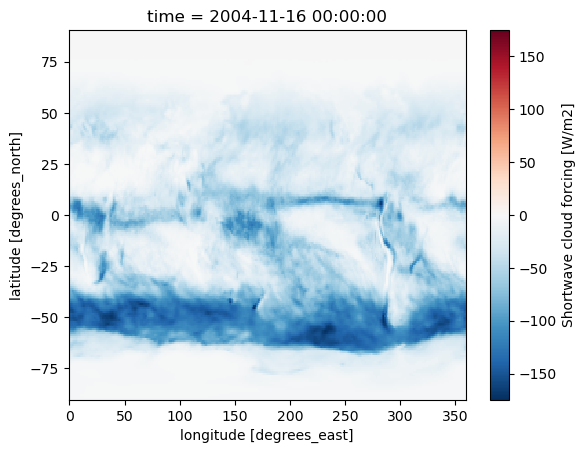

In [8]:
test.SWCF.plot()

In [23]:
ds_list = []
run_id = []

for case in cases:
    
    run_id.append(int(case.split("/")[-1][-3:]))
    print(f'{case} : {int(case.split("/")[-1][-3:])}')
    time_files = glob.glob(os.path.join(case, "atm/hist",  "*h0a*"))
    sim_per = xr.open_mfdataset(time_files, combine='by_coords', chunks = {"time":1})
    
    sim_par = sim_per[voi].mean(dim = "time")
    
    ds_list.append(sim_par)

/glade/derecho/scratch/addisus/archive/run.089 : 89


In [10]:
ds_ta = xr.concat(ds_list, dim=pd.Index(run_id, name="ppe_ind"))
ds_ta = ds_ta.sortby("ppe_ind")

In [11]:
ds_ta = ds_ta.compute()

In [21]:
ds_ta["RESTOM"] = ds_ta["FSNT"] - ds_ta["FLNT"]
ds_ta["RESTOA"] = ds_ta["FSNTOA"] - ds_ta["FLUT"]


In [22]:
#ds_ta.to_netcdf("/glade/work/qingyuany/cam7/ppe_time_average_nc/ppe1.nc")

In [30]:
import numpy as np
np.diff(sim_per['FSNTC'].lon)

array([1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25,
       1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25,
       1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25,
       1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25,
       1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25,
       1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25,
       1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25,
       1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25,
       1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25,
       1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25,
       1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25,
       1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25,
       1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25,
       1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.

2025-12-04 08:18:06,925 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/distributed/comm/tcp.py", line 225, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/distributed/worker.py", line 1269, in heartbeat
    response = await retry_operation(
               ^^^^^^^^^^^^^^^^^^^^^^
  File "/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/distributed/utils_comm.py", line 441, in retry_operation
    return await retry(
           ^^^^^^^^^^^^
  File "/glade/work/qingyuany/conda-envs/ml_env/lib/python3.

In [12]:



para = xr.open_dataset("/glade/work/addisus/scam_scripts/PPE_250_ensemble/parameter38_100.nc")

In [13]:
para = para.to_dataframe()
para["Sample_nmb"] = para["Sample_nmb"].astype(int)
para = para.set_index("Sample_nmb")
para.index.name = "ppe_ind"


In [15]:
ppe = pd.read_csv("/glade/work/qingyuany/cam7/tabs/ppe1.csv", index_col=0)

In [ ]:
para.to_csv("/glade/work/qingyuany/cam7/para/ppe0")

In [22]:
para  = para[para.index.isin(ppe.index)]

In [25]:
para.to_csv("/glade/work/qingyuany/cam7/para/ppe0_original_scale.csv")